In [3]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m
import scipy.optimize as sci

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
import file_utils
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/June_July2025"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Aug2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

In [4]:
def msd_func(x, a ,b):
    return(a*x + b)

[0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
[1.0004, 1.0037, 1.0994, 1.3995, 9.2211, 24.4776, 128.3052, 219.2768] 

[ 0.88747655 -6.56025602]
[ 0.86387623 -5.77923458]
[ 0.9055519  -4.59229503]
[ 0.89719308 -3.92716045]
[ 0.996406   -0.83571029]
[1.00389256 0.58683149]
[ 0.50387799 10.12441399]
[ 0.49765161 11.1264483 ]


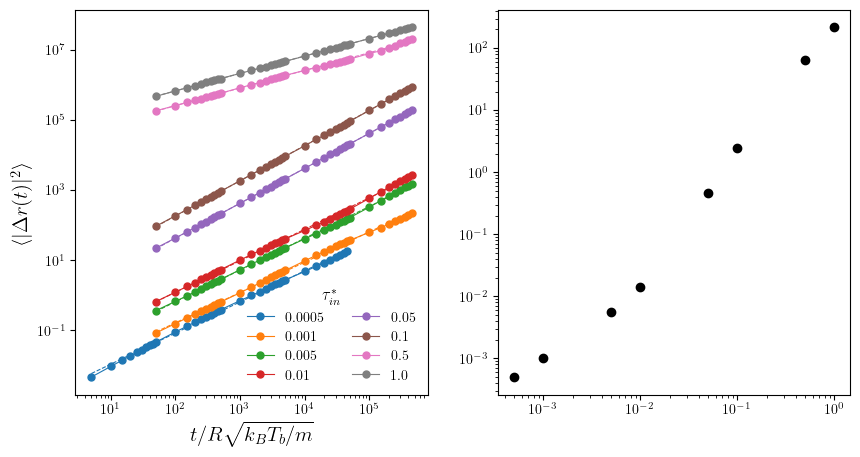

In [18]:
lw = 0.8
ms = 5

Pe = 90
plot_list = [37, 38, 40, 41, 43, 44, 46, 47]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fpath = os.path.join(dirpath, "Pe{pe}".format(pe = Pe), "avgTemp.dat")
[data, _] = readData(fpath, 1)

nr = data[0]
tau_in = data[1]
T = data[4]

tau_list = [tau_in[nr.index(plot_list[i])] for i in range(len(plot_list))]
T_list = [T[nr.index(plot_list[i])] for i in range(len(plot_list))]
D_eff = [tau_list[i]*T_list[i] for i in range(len(plot_list))]

print(tau_list)
print(T_list, "\n")
last = 36

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
for i in range(len(plot_list)):

    fpath = os.path.join(dirpath, "Pe{pe}".format(pe = Pe), "Data{nr}".format(nr = plot_list[i]), "msd.dat")

    [data, _] = readData(fpath, 1)
    time = data[0][0:last]
    msd = data[4][0:last]

    coeff = sci.curve_fit(msd_func, np.log(time), np.log(msd))[0]
    print(coeff)

    msd_th = [np.exp(coeff[1])*t**coeff[0] for t in time]

    ax[0].loglog(time, msd, "o-", color = colors[i], lw = lw, ms = ms, label = r"${tau}$".format(tau = tau_list[i]))
    ax[0].loglog(time, msd_th, "--", color = colors[i], lw = lw, ms = ms)

    # msd_th = [4*tau_list[i]*T_list[i]*t for t in time]
    # ax[0].loglog(time, msd_th, "--", color = colors[i], lw = 2*lw, ms = ms)

ax[1].loglog(tau_list, D_eff, "ko")

ax[0].set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 15)
ax[0].set_ylabel(r"$\langle|\Delta r(t)|^2\rangle$", fontsize = 15)
leg = ax[0].legend(title = r"$\tau_{in}^*$", fontsize = 10, ncols = 2, frameon = False, loc = "lower right")
leg.get_title().set_fontsize("12")